In [263]:
%load_ext autoreload
%autoreload 2
import sys
import os

ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [264]:
#HumanCT_res_df_GeneL = pd.read_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.June10.csv", index_col=0)
#HumanCT_res_df_GeneL.head(5)

In [265]:
ExpL = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.CT.Exp.Entrez.csv", index_col=0)
ExpL.columns = [int(x) for x in ExpL.columns.values]
ExpL = ExpL.applymap(lambda x: np.log2(x + 1))

/home/jw3514/tmp/ipykernel_64685/270872365.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ExpL = ExpL.applymap(lambda x: np.log2(x + 1))


In [266]:
TPM = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.Filt.csv", index_col=0)
TPM = np.log1p(TPM)
TPM.columns = [int(x) for x in TPM.columns.values ]

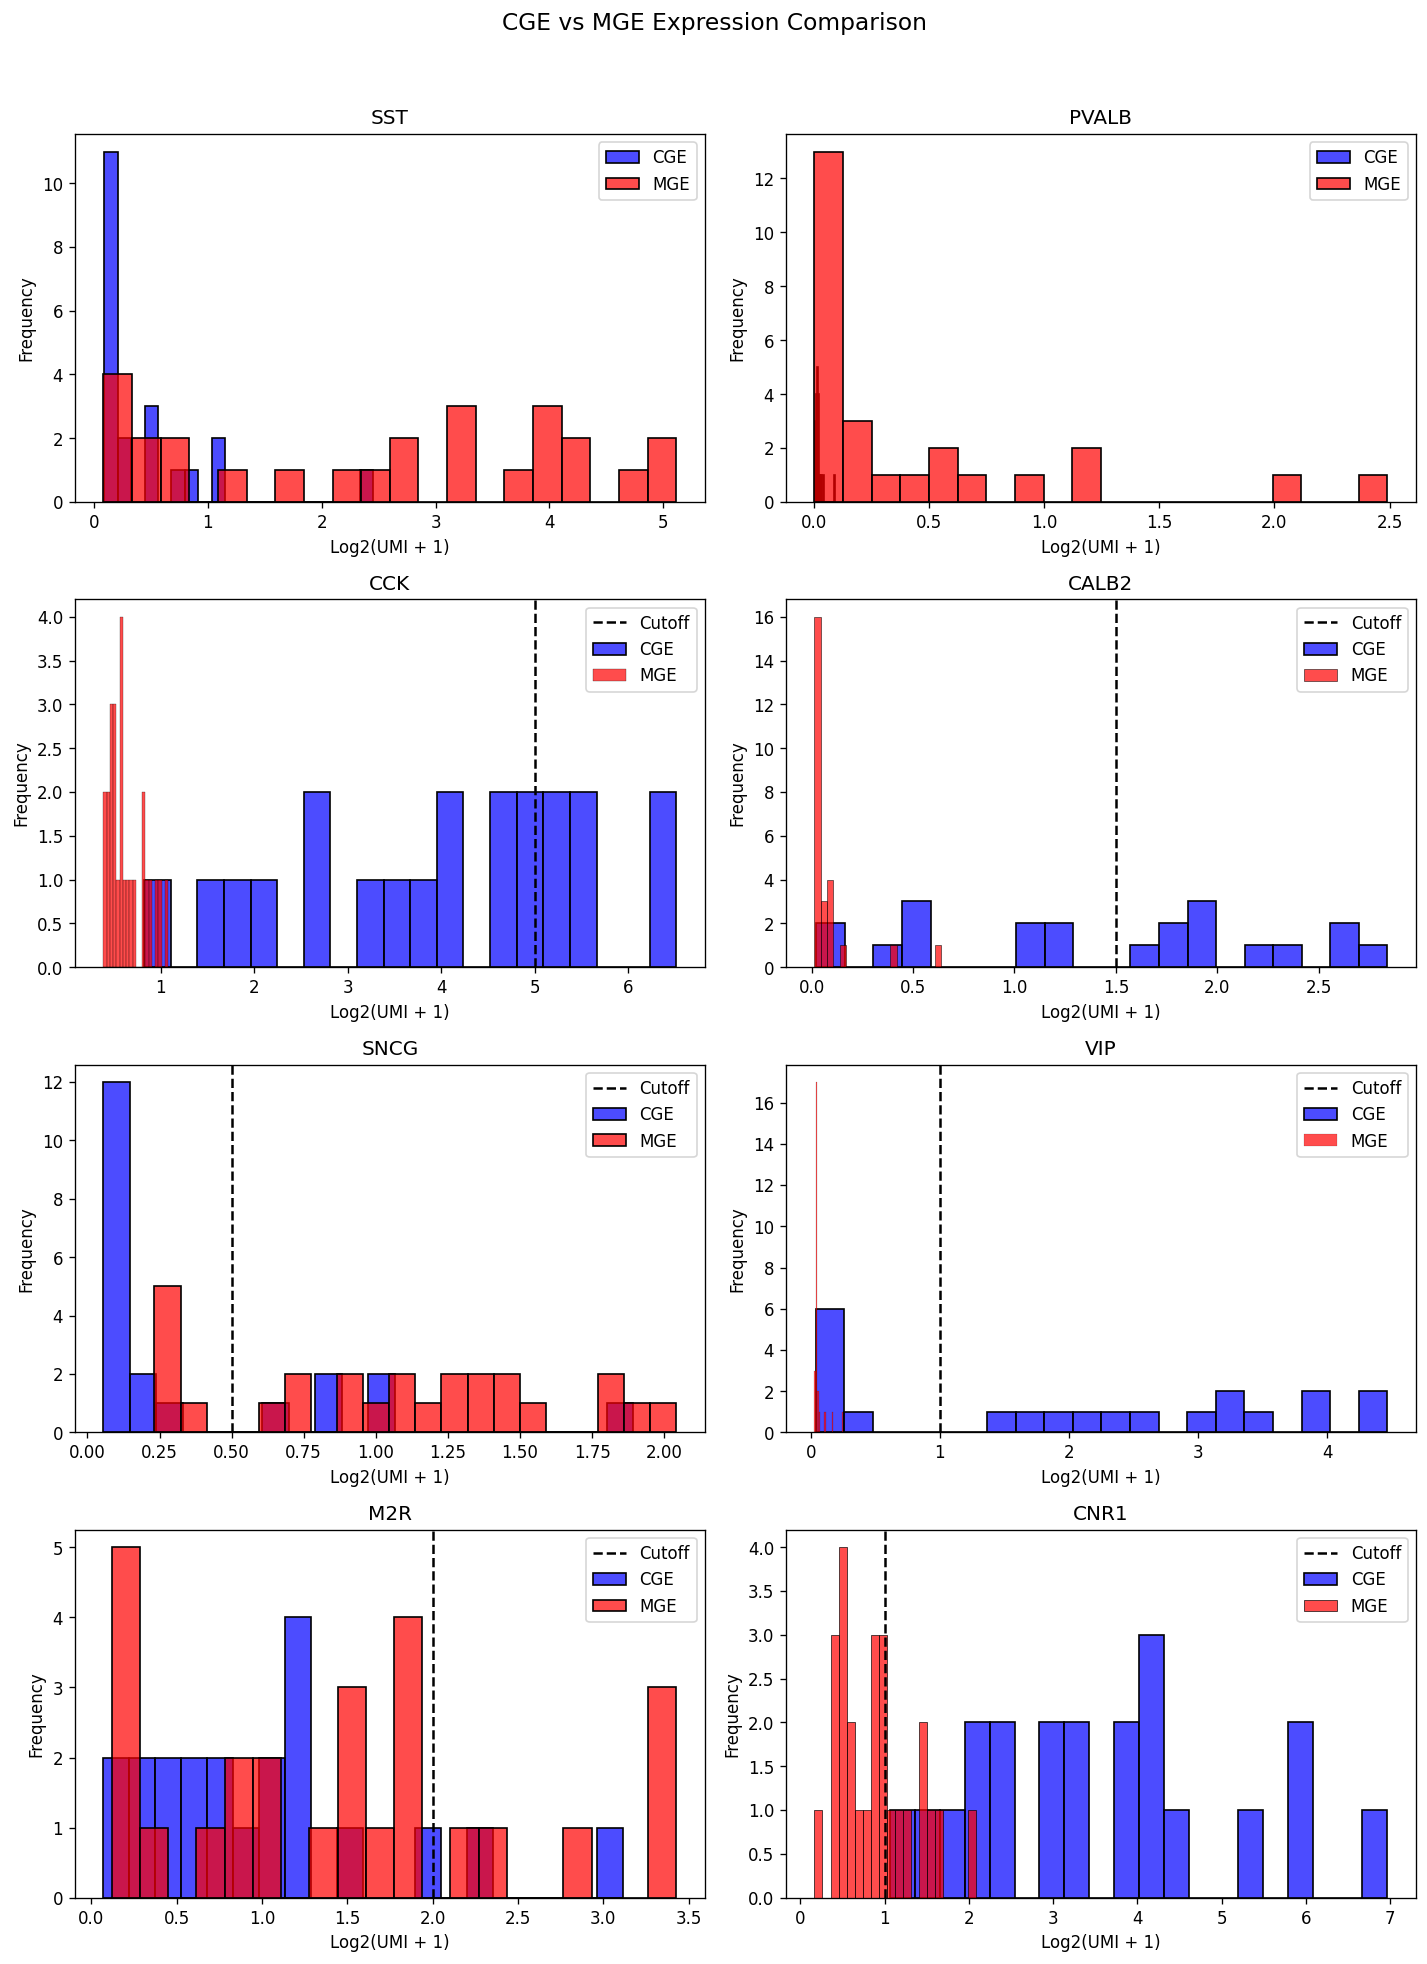

In [267]:
CGE_idx = Anno[Anno["Supercluster"]=="CGE interneuron"].index.values
MGE_idx = Anno[Anno["Supercluster"]=="MGE interneuron"].index.values

# Define markers to plot
markers = {
    'SST': GeneSymbol2Entrez["SST"],
    'PVALB': GeneSymbol2Entrez["PVALB"],
    "CCK": GeneSymbol2Entrez["CCK"],
    "CALB2": GeneSymbol2Entrez["CALB2"],
    "SNCG": GeneSymbol2Entrez["SNCG"],
    "VIP": GeneSymbol2Entrez["VIP"],
    "M2R": GeneSymbol2Entrez["CHRM2"],
    "CNR1": GeneSymbol2Entrez["CNR1"]
}

cutoffs = {
    "VIP": 1,
    "CCK": 5,
    "CR": 1.5,
    "SNCG": 0.5,
    "M2R": 2,
    "CNR1": 1
}

# Calculate number of rows needed (2 markers per row)
n_markers = len(markers)
n_cols = 2
n_rows = math.ceil(n_markers / n_cols)

# Create subplot layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows), dpi=120)
fig.suptitle("CGE vs MGE Expression Comparison", fontsize=14, y=1.02)

# Flatten axes array for easier indexing
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, (marker_name, entrez_id) in enumerate(markers.items()):
    cge_expr = ExpL.loc[entrez_id, CGE_idx]
    mge_expr = ExpL.loc[entrez_id, MGE_idx]
    ax = axes[idx]
    sns.histplot(cge_expr, bins=20, ax=ax, color='blue', alpha=0.7, label='CGE')
    sns.histplot(mge_expr, bins=20, ax=ax, color='red', alpha=0.7, label='MGE')
    ax.set_title(f"{marker_name}")
    ax.set_xlabel("Log2(UMI + 1)")
    ax.set_ylabel("Frequency")
    ax.legend()

    # Add vertical line for cutoff if available
    cutoff_val = None
    # We match marker_name to key in cutoffs (marker_name or e.g. 'CR' for 'CALB2')
    cutoff_key = marker_name
    if marker_name == "CALB2":
        cutoff_key = "CR"  # CALB2 is the gene, CR is the marker label for cutoff
    if cutoff_key in cutoffs:
        cutoff_val = cutoffs[cutoff_key]
    if cutoff_val is not None:
        ax.axvline(cutoff_val, color="k", linestyle="--", linewidth=1.5, label="Cutoff")
        # To avoid duplicate legends, only add cutoff to one handle per ax
        handles, labels = ax.get_legend_handles_labels()
        # Remove duplicate "Cutoff" if already present
        if labels.count("Cutoff") > 1:
            cutoff_indices = [i for i, label in enumerate(labels) if label == "Cutoff"]
            for i in cutoff_indices[1:]:
                del handles[i]
                del labels[i]
        ax.legend(handles, labels)

# Hide any unused subplots
for idx in range(n_markers, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [282]:
#Bias_Save_Dict = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jun09/"
#Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jul07/"
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/results/random/Centering/"

SCZ_Bias = pd.read_csv(Bias_Save_Dir + "SCZ_bias_addP.csv", index_col=0)
HighIQ_ASD_Bias = pd.read_csv(Bias_Save_Dir + "ASD_HIQ_bias_addP.csv", index_col=0)
LowIQ_ASD_Bias = pd.read_csv(Bias_Save_Dir + "ASD_LIQ_bias_addP.csv", index_col=0)
X22q_Bias = pd.read_csv(Bias_Save_Dir + "22q_del_bias_addP.csv", index_col=0)
X22q_mouse_Bias = pd.read_csv(Bias_Save_Dir + "22q_small_del_bias_addP.csv", index_col=0)
DDD_Bias = pd.read_csv(Bias_Save_Dir + "DDD_61_bias_addP.csv", index_col=0)

# VNR_Pos_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_VNR_Pos_bias_addP.csv", index_col=0)
# VNR_Neg_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_VNR_Neg_Bias_addP.csv", index_col=0)
# EDU_Pos_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_EDU_Pos_Bias_addP.csv", index_col=0)
# EDU_Neg_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_EDU_Neg_Bias_addP.csv", index_col=0)

#VNR_Pos_Bias = pd.read_csv(os.path.join(Bias_Save_Dict, "CTBias.VNR.Pos.top61.csv"), index_col=0)
#VNR_Neg_Bias = pd.read_csv(os.path.join(Bias_Save_Dict, "CTBias.VNR.Neg.top61.csv"), index_col=0)
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jul24_Centered/"
X22q_Hexp_Bias = pd.read_csv("{}/HCT.22q.HighExp.csv".format(Bias_Save_Dir), index_col=0)
X22q_DEG_day25_Bias = pd.read_csv("{}/DEG_22q_day25_Bias.csv".format(Bias_Save_Dir), index_col=0)
X22q_DEG_day50_Bias = pd.read_csv("{}/DEG_22q_day50_Bias.csv".format(Bias_Save_Dir), index_col=0)
X22q_DEG_day75_Bias = pd.read_csv("{}/DEG_22q_day75_Bias.csv".format(Bias_Save_Dir), index_col=0)
X22q_DEG_day100_Bias = pd.read_csv("{}/DEG_22q_day100_Bias.csv".format(Bias_Save_Dir), index_col=0)

In [283]:
#BiasDFs = [X22q_Bias, HighIQ_ASD_Bias, LowIQ_ASD_Bias, VNR_Pos_Bias, VNR_Neg_Bias, DDD_Bias, SCZ_Bias]
BiasDFs = [X22q_Bias, X22q_mouse_Bias,  X22q_Hexp_Bias, X22q_DEG_day25_Bias, X22q_DEG_day50_Bias, X22q_DEG_day75_Bias, X22q_DEG_day100_Bias]
BiasDF_Names = ["X22q", "X22q_mouse", "X22q_Hexp", "X22q_DEG_day25", "X22q_DEG_day50", "X22q_DEG_day75", "X22q_DEG_day100"]
for i, row in X22q_Bias.iterrows():
    for BiasDF, name in zip(BiasDFs, BiasDF_Names):
        X22q_Bias.loc[i, name+"_Bias"] = BiasDF.loc[i, "EFFECT"]

In [284]:
#TmpDF = X22q_Bias[["Class","Supercluster","X22q_Bias", "X22q_mouse_Bias", "LowIQ_ASD_Bias", "VNR_Pos_Bias", "VNR_Neg_Bias", "DDD_Bias", "SCZ_Bias"]]
TmpDF = X22q_Bias[["Class","Supercluster","X22q_Bias", "X22q_mouse_Bias", "X22q_Hexp_Bias", "X22q_DEG_day25_Bias", "X22q_DEG_day50_Bias", "X22q_DEG_day75_Bias", "X22q_DEG_day100_Bias"]]

In [285]:
# More efficient, avoids chained assignment warnings and uses .loc for columns in bulk

Biases_CGE_ExpL = TmpDF[TmpDF["Supercluster"] == "CGE interneuron"].copy()

# List marker gene names and their column suffixes
marker_genes = {
    "VIP_ExpL": "VIP",
    "CCK_ExpL": "CCK",
    "CR_ExpL": "CALB2",
    "SNCG_ExpL": "SNCG",
    "M2R_ExpL": "CHRM2",
    "CNR1_ExpL": "CNR1"
}

for colname, symbol in marker_genes.items():
    entrez_id = GeneSymbol2Entrez[symbol]
    # Extract matching columns in proper order
    Biases_CGE_ExpL.loc[:, colname] = ExpL.loc[entrez_id, Biases_CGE_ExpL.index].values


In [286]:
Biases_CGE_ExpL.sort_values(by="X22q_Bias", ascending=False, inplace=True)
#Biases_CGE_ExpL

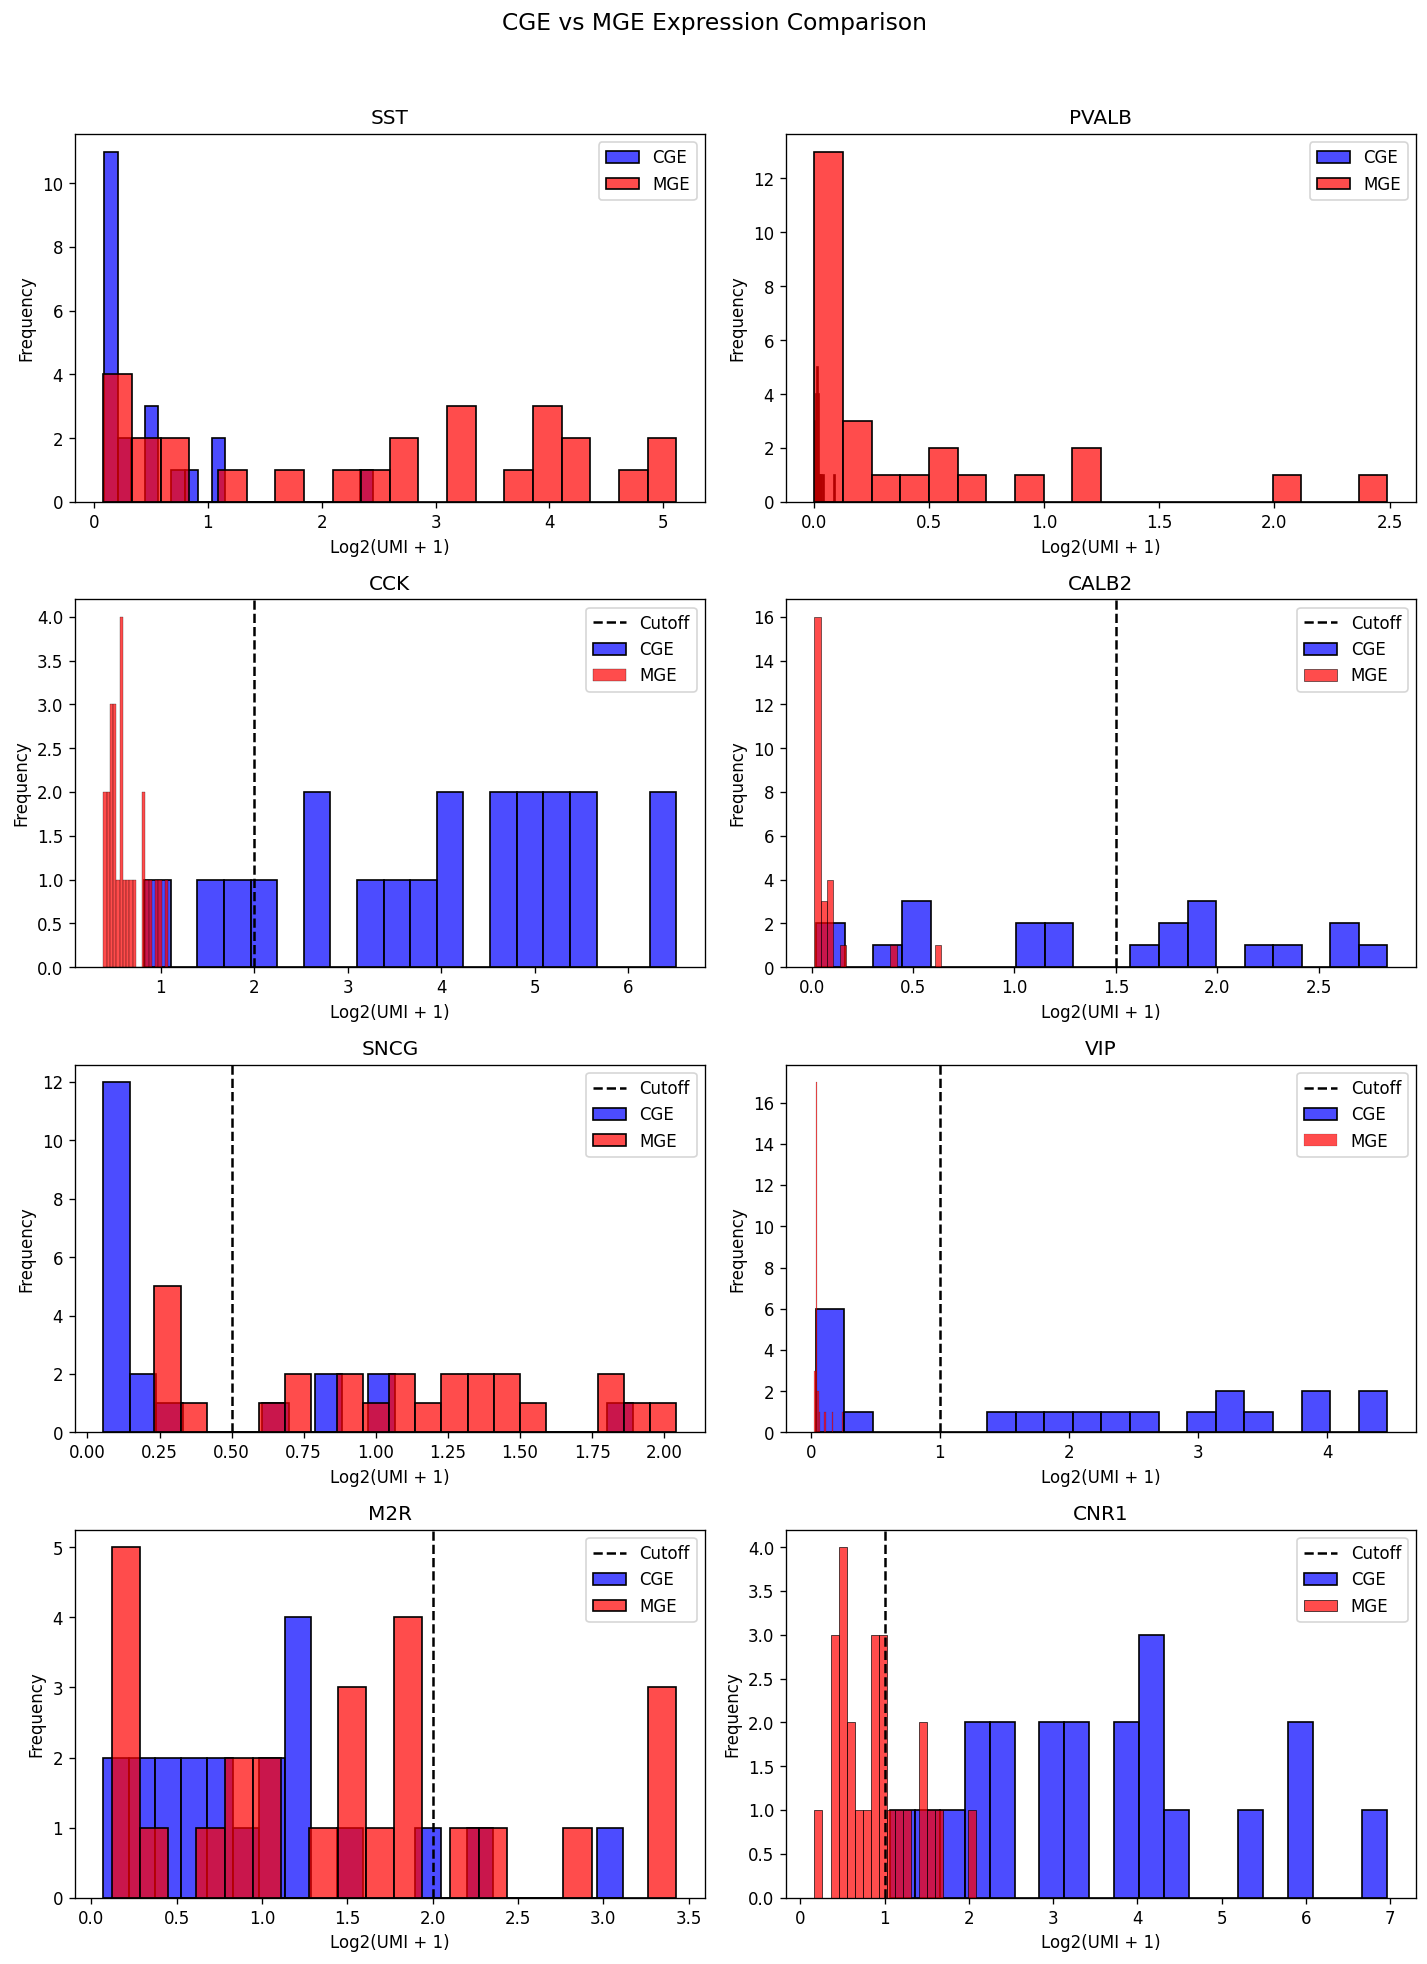

In [287]:
CGE_idx = Anno[Anno["Supercluster"]=="CGE interneuron"].index.values
MGE_idx = Anno[Anno["Supercluster"]=="MGE interneuron"].index.values

# Define markers to plot
markers = {
    'SST': GeneSymbol2Entrez["SST"],
    'PVALB': GeneSymbol2Entrez["PVALB"],
    "CCK": GeneSymbol2Entrez["CCK"],
    "CALB2": GeneSymbol2Entrez["CALB2"],
    "SNCG": GeneSymbol2Entrez["SNCG"],
    "VIP": GeneSymbol2Entrez["VIP"],
    "M2R": GeneSymbol2Entrez["CHRM2"],
    "CNR1": GeneSymbol2Entrez["CNR1"]
}

cutoffs = {
    "VIP": 1,
    "CCK": 2,
    "CR": 1.5,
    "SNCG": 0.5,
    "M2R": 2,
    "CNR1": 1
}

# Calculate number of rows needed (2 markers per row)
n_markers = len(markers)
n_cols = 2
n_rows = math.ceil(n_markers / n_cols)

# Create subplot layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows), dpi=120)
fig.suptitle("CGE vs MGE Expression Comparison", fontsize=14, y=1.02)

# Flatten axes array for easier indexing
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, (marker_name, entrez_id) in enumerate(markers.items()):
    cge_expr = ExpL.loc[entrez_id, CGE_idx]
    mge_expr = ExpL.loc[entrez_id, MGE_idx]
    ax = axes[idx]
    sns.histplot(cge_expr, bins=20, ax=ax, color='blue', alpha=0.7, label='CGE')
    sns.histplot(mge_expr, bins=20, ax=ax, color='red', alpha=0.7, label='MGE')
    ax.set_title(f"{marker_name}")
    ax.set_xlabel("Log2(UMI + 1)")
    ax.set_ylabel("Frequency")
    ax.legend()

    # Add vertical line for cutoff if available
    cutoff_val = None
    # We match marker_name to key in cutoffs (marker_name or e.g. 'CR' for 'CALB2')
    cutoff_key = marker_name
    if marker_name == "CALB2":
        cutoff_key = "CR"  # CALB2 is the gene, CR is the marker label for cutoff
    if cutoff_key in cutoffs:
        cutoff_val = cutoffs[cutoff_key]
    if cutoff_val is not None:
        ax.axvline(cutoff_val, color="k", linestyle="--", linewidth=1.5, label="Cutoff")
        # To avoid duplicate legends, only add cutoff to one handle per ax
        handles, labels = ax.get_legend_handles_labels()
        # Remove duplicate "Cutoff" if already present
        if labels.count("Cutoff") > 1:
            cutoff_indices = [i for i, label in enumerate(labels) if label == "Cutoff"]
            for i in cutoff_indices[1:]:
                del handles[i]
                del labels[i]
        ax.legend(handles, labels)

# Hide any unused subplots
for idx in range(n_markers, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [288]:
# Use cutoffs from the dict defined above (keyed by feature/column names)
VIP_Pos = Biases_CGE_ExpL[Biases_CGE_ExpL["VIP_ExpL"] > cutoffs["VIP"]]
VIP_Neg = Biases_CGE_ExpL[Biases_CGE_ExpL["VIP_ExpL"] < cutoffs["VIP"]]

# Access cutoffs for each marker
CCK_Cutoff = cutoffs["CCK"]
CR_Cutoff = cutoffs["CR"]
SNCG_Cutoff = cutoffs["SNCG"]
M2R_Cutoff = cutoffs["M2R"]

# Main subpopulation selections
CCKBC = Biases_CGE_ExpL[
    (Biases_CGE_ExpL["CR_ExpL"] < CR_Cutoff)
    & (Biases_CGE_ExpL["SNCG_ExpL"] > SNCG_Cutoff)
    & (Biases_CGE_ExpL["CCK_ExpL"] > CCK_Cutoff)
    & (Biases_CGE_ExpL["M2R_ExpL"] < M2R_Cutoff)
]
ISI2 = VIP_Pos[
    (VIP_Pos["CR_ExpL"] < CR_Cutoff)
    & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)
    & (VIP_Pos["SNCG_ExpL"] < SNCG_Cutoff)
]
ISI3 = VIP_Pos[
    (VIP_Pos["CR_ExpL"] > CR_Cutoff)
    & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)
    & (VIP_Pos["SNCG_ExpL"] < SNCG_Cutoff)
]

# Combine indices and get the "Other" group
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

2 2 6 4


In [289]:
CCKBC

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,X22q_Hexp_Bias,X22q_DEG_day25_Bias,X22q_DEG_day50_Bias,X22q_DEG_day75_Bias,X22q_DEG_day100_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
279,NEUR,CGE interneuron,0.149702,0.163487,0.218760,0.159664,0.190645,0.147359,0.223803,1.986810,6.514816,1.016572,1.008213,1.493213,6.964685
276,NEUR,CGE interneuron,0.069572,0.041988,0.170379,0.126069,0.257270,0.084336,0.218721,3.289735,4.680021,0.518729,1.892765,1.210653,5.811609


In [290]:
ISI2

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,X22q_Hexp_Bias,X22q_DEG_day25_Bias,X22q_DEG_day50_Bias,X22q_DEG_day75_Bias,X22q_DEG_day100_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
280,NEUR,CGE interneuron,0.149726,0.164484,0.279482,0.164652,0.219948,0.155175,0.259179,1.515110,6.306079,1.218876,0.090617,0.472981,5.293350
296,NEUR,CGE interneuron,0.140227,0.084468,0.269742,0.169783,0.254595,0.162454,0.242348,3.901326,3.964441,1.247704,0.064868,0.567487,3.733591


In [291]:
ISI3

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,X22q_Hexp_Bias,X22q_DEG_day25_Bias,X22q_DEG_day50_Bias,X22q_DEG_day75_Bias,X22q_DEG_day100_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
293,NEUR,CGE interneuron,0.171896,0.185311,0.278656,0.273369,0.211190,0.163304,0.250423,3.902905,4.615708,1.845215,0.086956,0.569426,2.400006
295,NEUR,CGE interneuron,0.170202,0.156127,0.267545,0.236272,0.204966,0.176287,0.246470,4.302556,5.478905,2.597560,0.067847,0.168296,4.302793
294,NEUR,CGE interneuron,0.149910,0.123391,0.272058,0.268365,0.242132,0.188822,0.266238,4.467030,4.839550,1.931784,0.154624,0.342481,3.816998
284,NEUR,CGE interneuron,0.121431,0.084004,0.246451,0.151782,0.280574,0.175210,0.246321,2.675035,0.823129,2.270137,0.068208,1.069718,2.172299
292,NEUR,CGE interneuron,0.090834,0.090868,0.196190,0.154022,0.117610,0.152191,0.160686,3.382103,5.137369,2.838481,0.271150,1.237310,4.016405
289,NEUR,CGE interneuron,0.086774,0.033076,0.185277,0.139315,0.181638,0.144239,0.144836,2.095320,2.542674,1.699866,0.074574,1.147712,2.075602


In [292]:
Other

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,X22q_Hexp_Bias,X22q_DEG_day25_Bias,X22q_DEG_day50_Bias,X22q_DEG_day75_Bias,X22q_DEG_day100_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
281,NEUR,CGE interneuron,0.149497,0.146209,0.305006,0.188422,0.278737,0.170757,0.312560,2.425814,5.115881,1.830600,0.822954,0.444442,5.960080
291,NEUR,CGE interneuron,0.132346,0.131861,0.230889,0.163532,0.165776,0.164564,0.208149,1.741167,2.018184,2.302706,0.992792,1.116293,2.934489
285,NEUR,CGE interneuron,0.109779,0.098717,0.247608,0.184819,0.261920,0.179562,0.291924,3.330917,3.499002,2.694272,0.690177,0.880221,3.242150
290,NEUR,CGE interneuron,0.083791,0.059582,0.186617,0.158292,0.094047,0.135745,0.121344,2.943066,3.155312,1.952893,0.140754,2.212492,1.719494


In [293]:
VIP_Neg

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,X22q_Hexp_Bias,X22q_DEG_day25_Bias,X22q_DEG_day50_Bias,X22q_DEG_day75_Bias,X22q_DEG_day100_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
288,NEUR,CGE interneuron,0.125923,0.128409,0.263688,0.205839,0.293620,0.135827,0.340538,0.063092,4.054386,0.022998,0.080230,0.724959,1.367394
286,NEUR,CGE interneuron,0.098854,0.081765,0.225611,0.191746,0.263387,0.163144,0.306133,0.064754,2.767076,0.389279,0.068375,0.071371,2.527133
282,NEUR,CGE interneuron,0.098372,0.037832,0.196905,0.130171,0.164815,0.113104,0.207922,0.260284,4.913331,0.571570,0.055122,1.281136,4.122053
283,NEUR,CGE interneuron,0.093752,0.033059,0.214947,0.150402,0.191722,0.155739,0.234728,0.170588,1.600478,1.932879,0.088133,0.693537,3.299220
287,NEUR,CGE interneuron,0.088499,0.079107,0.231588,0.180379,0.260534,0.109958,0.301705,0.037270,3.707397,0.024418,0.096741,0.345491,1.066311
277,NEUR,CGE interneuron,0.040994,0.038415,0.172136,0.144753,0.195062,0.127552,0.231536,0.064130,1.800594,1.041795,0.858644,3.116183,2.933801
278,NEUR,CGE interneuron,0.013591,-0.008719,0.119498,0.142731,0.163503,0.127045,0.205740,0.112676,5.524440,0.538041,0.154092,2.019814,4.334088


In [294]:
def plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias"):
    plt.figure(figsize=(8,6))

    # Create boxplot
    bp = plt.boxplot([CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label]],
                     tick_labels=['CCKBC', 'ISI2', 'ISI3', 'Other', 'VIP-'])

    # Add individual points with jitter
    for i, data in enumerate([CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label]], 1):
        x = np.random.normal(i, 0.04, size=len(data))
        plt.plot(x, data, 'o', alpha=0.5, color='black', markersize=4)

    plt.ylabel(label)
    plt.title(label)

    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label])
    plt.text(0.02, 0.98, f'Kruskal-Wallis p={p_val:.2e}', 
             transform=plt.gca().transAxes, verticalalignment='top')

    plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_beta_distribution(
    CCKBC, ISI2, ISI3, Other, VIP_Neg,
    label="X22q_Bias",
    figsize=(4.8, 3.6),
    jitter=0.06):
    fig, ax = plt.subplots(figsize=figsize)

    groups = [
        CCKBC[label],
        ISI2[label],
        ISI3[label],
        Other[label],
        VIP_Neg[label]
    ]
    group_labels = ['CCKBC', 'ISI2', 'ISI3', 'Other', 'VIP−']

    # --- Boxplot (lighter, transparent) ---
    bp = ax.boxplot(
        groups,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=1.4),
        boxprops=dict(
            facecolor='lightgray',
            edgecolor='black',
            linewidth=1.2,
            alpha=0.35
        ),
        whiskerprops=dict(color='black', linewidth=1.1),
        capprops=dict(color='black', linewidth=1.1)
    )

    # --- Overlay individual points (larger, prominent) ---
    for i, data in enumerate(groups, 1):
        x = np.random.normal(i, jitter, size=len(data))
        ax.scatter(
            x, data,
            s=28,                # ⬅ bigger dots
            color='black',
            alpha=0.75,
            edgecolors='black',  # ⬅ outline for visibility
            linewidths=0.3,
            zorder=3
        )

    # --- Axes formatting ---
    ax.set_xticks(range(1, len(group_labels) + 1))
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, pad=6)

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)

    # --- Statistics ---
    h_stat, p_kw = stats.kruskal(*groups)
    _, p_isi2 = stats.mannwhitneyu(
        ISI2[label], CCKBC[label], alternative='greater'
    )
    _, p_isi3 = stats.mannwhitneyu(
        ISI3[label], CCKBC[label], alternative='greater'
    )
    _, p_isi23_cck = stats.mannwhitneyu(
        list(ISI2[label]) + list(ISI3[label]), list(CCKBC[label]), alternative='greater'
    )

    _, p_isi23_vip_neg = stats.mannwhitneyu(
        list(ISI2[label]) + list(ISI3[label]), list(VIP_Neg[label]), alternative='greater'
    )
    # stat_text = (
    #     f"Kruskal–Wallis p = {p_kw:.2e}\n"
    #     f"ISI2 > CCKBC: p = {p_isi2:.2e}\n"
    #     f"ISI3 > CCKBC: p = {p_isi3:.2e}"
    # )

    stat_text = (
        f"Kruskal–Wallis p = {p_kw:.2e}\n"
        f"ISI2+ISI3 > CCKBC: p = {p_isi23_cck:.2e}\n"
        f"ISI2+ISI3 > VIP-: p = {p_isi23_vip_neg:.2e}\n"
    )

    ax.text(
        0.02, 0.98,
        stat_text,
        transform=ax.transAxes,
        fontsize=8,
        va='top'
    )

    plt.tight_layout()
    plt.show()


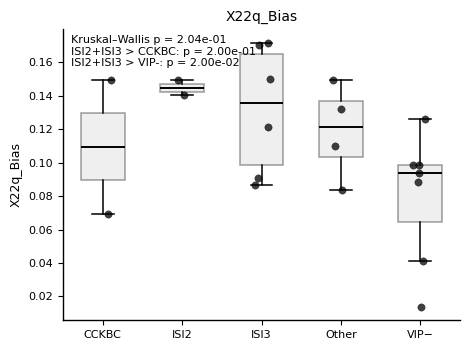

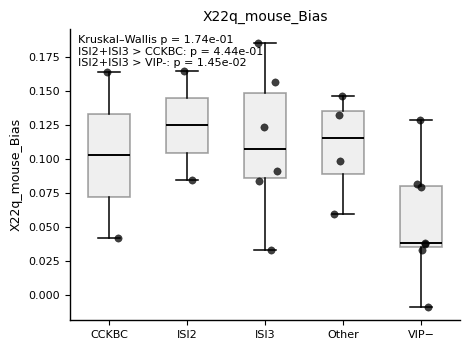

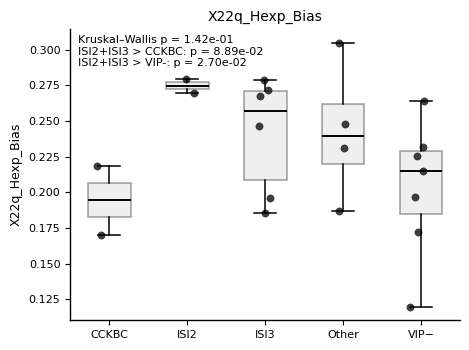

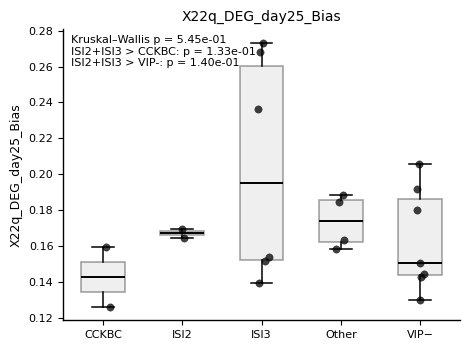

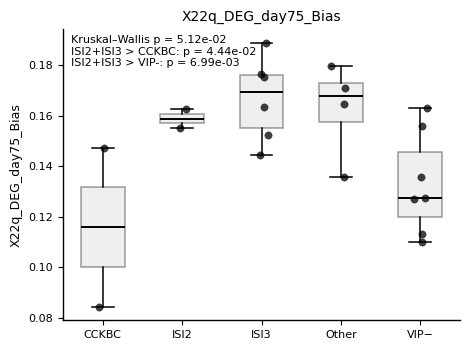

In [295]:
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_mouse_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Hexp_Bias")

plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day25_Bias")
#plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day50_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day75_Bias")
#plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day100_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="LowIQ_ASD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Pos_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Neg_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="DDD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="SCZ_Bias")

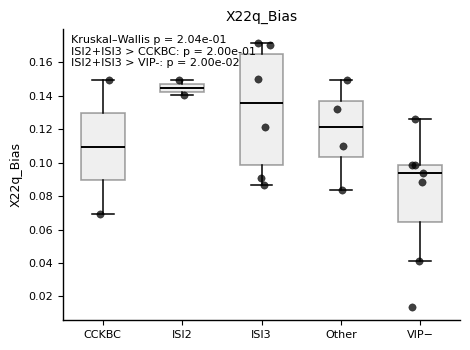

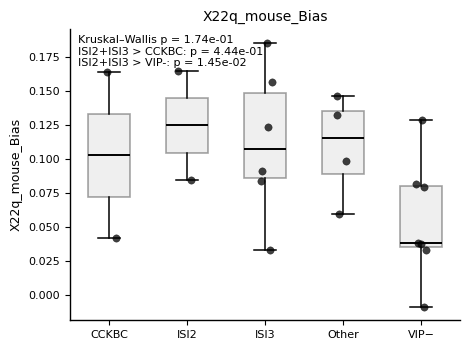

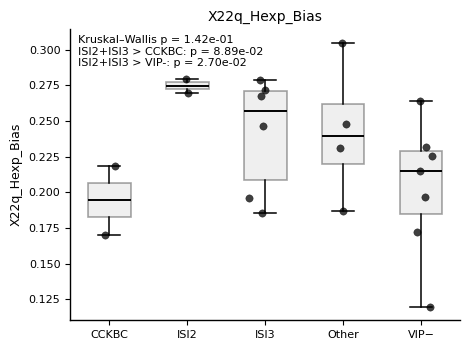

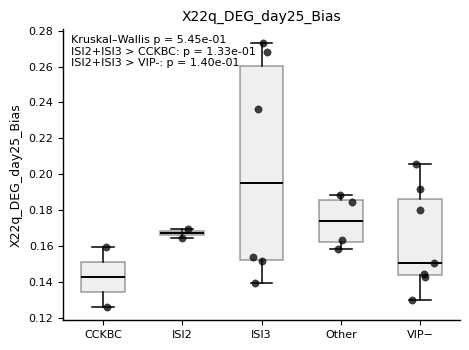

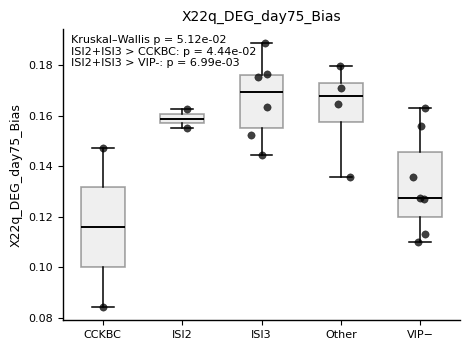

In [296]:
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_mouse_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Hexp_Bias")

plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day25_Bias")
#plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day50_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day75_Bias")
#plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_DEG_day100_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="LowIQ_ASD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Pos_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Neg_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="DDD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="SCZ_Bias")

### Try CPM instead of LogUMI

In [35]:
Biases_CGE = TmpDF[TmpDF["Supercluster"]=="CGE interneuron"]
Biases_CGE_TPM = Biases_CGE.copy()
Biases_CGE_TPM.loc[:, "VIP_ExpL"]  = TPM.loc[GeneSymbol2Entrez["VIP"],  Biases_CGE_TPM.index].values
Biases_CGE_TPM.loc[:, "CCK_ExpL"]  = TPM.loc[GeneSymbol2Entrez["CCK"],  Biases_CGE_TPM.index].values
Biases_CGE_TPM.loc[:, "CR_ExpL"]   = TPM.loc[GeneSymbol2Entrez["CALB2"], Biases_CGE_TPM.index].values
Biases_CGE_TPM.loc[:, "SNCG_ExpL"] = TPM.loc[GeneSymbol2Entrez["SNCG"], Biases_CGE_TPM  .index].values
Biases_CGE_TPM.loc[:, "M2R_ExpL"]  = TPM.loc[GeneSymbol2Entrez["CHRM2"], Biases_CGE_TPM.index].values
Biases_CGE_TPM.loc[:, "CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], Biases_CGE_TPM.index].values

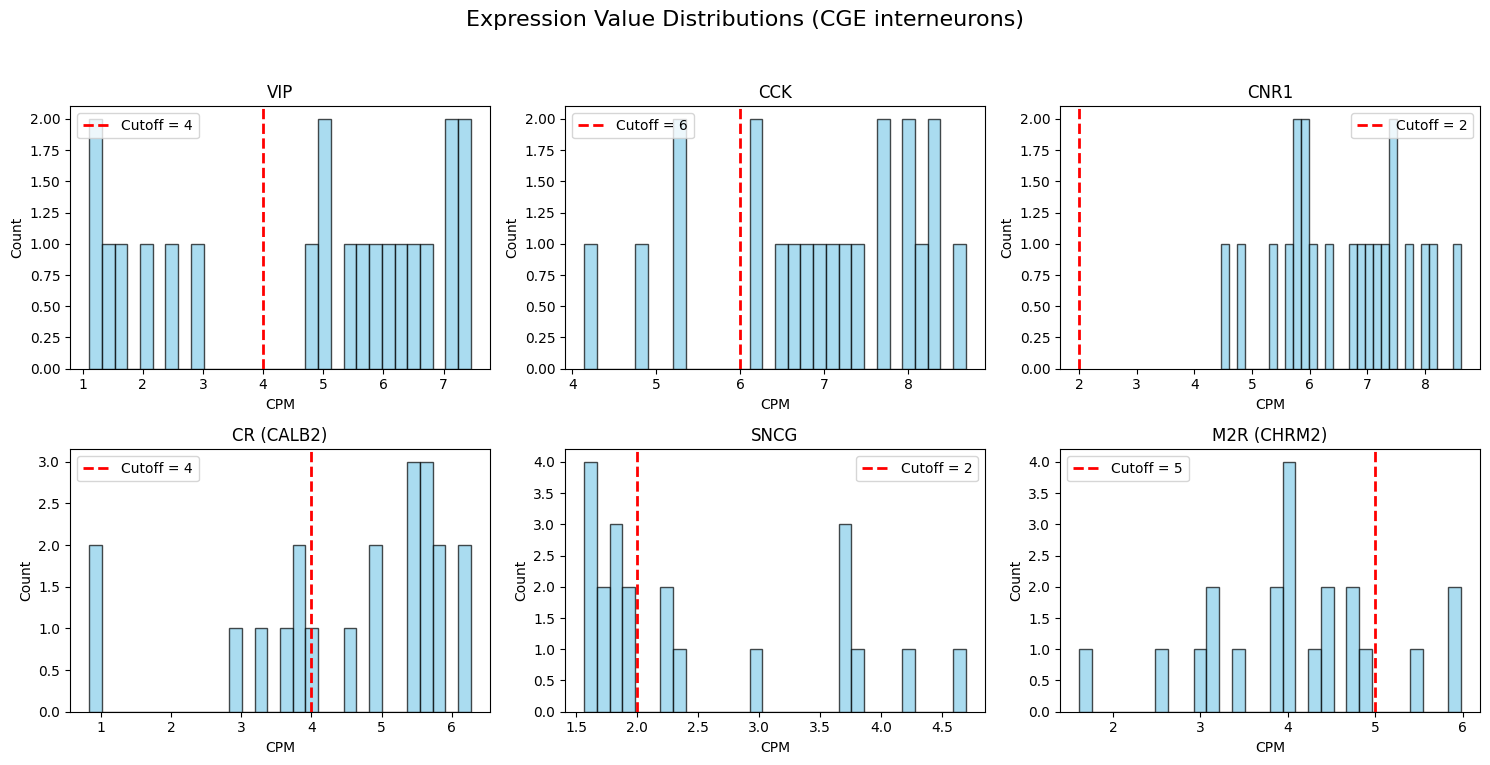

In [38]:
# -- Fixed: Dynamically compute rows/cols based on number of features to avoid IndexError --

import math

# Only include unique features for plotting (remove duplicate "CNR1_ExpL")
plot_feature_names = []
seen_cols = set()
for col, label in feature_names:
    if col not in seen_cols:
        plot_feature_names.append((col, label))
        seen_cols.add(col)

nplots = len(plot_feature_names)
ncols = 3
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
if nrows * ncols > 1:
    axes = axes.flatten()
else:
    axes = [axes]
fig.suptitle("Expression Value Distributions (CGE interneurons)", fontsize=16)

for idx, (col, label) in enumerate(plot_feature_names):
    ax = axes[idx]
    if col in Biases_CGE_TPM.columns:
        ax.hist(Biases_CGE_TPM[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        ax.set_title(label)
        ax.set_xlabel("CPM")
        ax.set_ylabel("Count")
        # Draw cutoff line if exists
        if cutoffs.get(col, None) is not None:
            ax.axvline(cutoffs[col], color='red', linestyle='--', linewidth=2, label=f"Cutoff = {cutoffs[col]}")
            ax.legend()
    else:
        ax.axis('off')

# Hide any unused axes (if feature count doesn't fill grid)
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [312]:
Biases_CGE_TPM.sort_values(by="SNCG_ExpL", ascending=False, inplace=True)
Biases_CGE_TPM[Biases_CGE_TPM["VIP_ExpL"]>VIP_Cutoff]

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL


In [39]:
VIP_Pos = Biases_CGE_TPM[Biases_CGE_TPM["VIP_ExpL"] > cutoffs["VIP_ExpL"]]
VIP_Neg = Biases_CGE_TPM[Biases_CGE_TPM["VIP_ExpL"] < cutoffs["VIP_ExpL"]]
# VIP_Cutoff = 100
# CCK_Cutoff = 1000
# CR_Cutoff = 200
# M2R_Cutoff = 100
# SNCG_Cutoff = 10
# CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
# ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
# ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

CCKBC = Biases_CGE_TPM[(Biases_CGE_TPM["CR_ExpL"] < cutoffs["CR_ExpL"]) 
    & (Biases_CGE_TPM["SNCG_ExpL"] > cutoffs["SNCG_ExpL"]) & (Biases_CGE_TPM["CCK_ExpL"] > cutoffs["CCK_ExpL"])]
ISI2 = VIP_Pos[(VIP_Pos["CR_ExpL"] < cutoffs["CR_ExpL"]) & (VIP_Pos["M2R_ExpL"] < cutoffs["M2R_ExpL"]) & (VIP_Pos["SNCG_ExpL"] < cutoffs["SNCG_ExpL"])] #& (VIP_Pos["SNCG_ExpL"] < SNCG_Cutoff)
ISI3 = VIP_Pos[(VIP_Pos["CR_ExpL"] > cutoffs["CR_ExpL"]) & (VIP_Pos["M2R_ExpL"] < cutoffs["M2R_ExpL"]) & (VIP_Pos["SNCG_ExpL"] < cutoffs["SNCG_ExpL"])]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

3 0 6 6


In [40]:
CCKBC

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
279,NEUR,CGE interneuron,0.149702,0.163487,4.894828,8.305889,3.845365,3.834123,4.409319,8.620605
276,NEUR,CGE interneuron,0.069572,0.041988,5.863158,6.893080,2.906407,4.695317,3.980169,7.698701
278,NEUR,CGE interneuron,0.013591,-0.008719,1.962584,8.129214,3.556514,2.250156,5.442854,7.275637


In [41]:
ISI2

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL


In [42]:
ISI3

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
293,NEUR,CGE interneuron,0.171896,0.185311,7.150044,7.671350,5.470222,1.897108,3.809757,5.969220
295,NEUR,CGE interneuron,0.170202,0.156127,7.453880,8.298260,6.145054,1.692911,2.517453,7.454053
280,NEUR,CGE interneuron,0.149726,0.164484,4.952165,8.683952,4.618788,1.775095,3.412171,7.969046
296,NEUR,CGE interneuron,0.140227,0.084468,7.152706,7.199484,4.843099,1.650730,3.809473,7.027663
284,NEUR,CGE interneuron,0.121431,0.084004,6.071581,4.139080,5.729836,1.586385,4.491061,5.643791
289,NEUR,CGE interneuron,0.086774,0.033076,5.761186,6.148560,5.387204,1.813734,4.775984,5.743362


In [44]:
Other

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
294,NEUR,CGE interneuron,0.149910,0.123391,7.414631,7.683420,5.403558,2.291396,3.093389,6.937106
281,NEUR,CGE interneuron,0.149497,0.146209,5.431296,7.468753,4.897654,3.713449,2.983844,8.066719
291,NEUR,CGE interneuron,0.132346,0.131861,5.056442,5.318890,5.572019,4.203634,4.366574,6.094697
285,NEUR,CGE interneuron,0.109779,0.098717,6.330122,6.458477,5.826839,3.661615,3.969682,6.261692
292,NEUR,CGE interneuron,0.090834,0.090868,6.699943,7.987717,6.274019,2.933759,4.769476,7.176187
290,NEUR,CGE interneuron,0.083791,0.059582,6.448722,6.615837,5.604979,2.366853,5.839912,5.381024


In [45]:
VIP_Neg

,Class,Supercluster,X22q_Bias,X22q_mouse_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,SNCG_ExpL,M2R_ExpL,CNR1_ExpL
288,NEUR,CGE interneuron,0.125923,0.128409,1.523945,7.134977,0.828799,1.721515,3.978458,4.851269
286,NEUR,CGE interneuron,0.098854,0.081765,1.534345,6.133948,3.240570,1.578282,1.613309,5.936451
282,NEUR,CGE interneuron,0.098372,0.037832,3.003719,7.946042,3.873520,1.563249,4.938849,7.372447
283,NEUR,CGE interneuron,0.093752,0.033059,2.545170,5.253254,5.578645,1.930752,4.073448,6.719702
287,NEUR,CGE interneuron,0.088499,0.079107,1.107870,6.841348,0.842741,1.852283,3.089564,4.451782
277,NEUR,CGE interneuron,0.040994,0.038415,1.203555,4.855285,4.013111,3.754812,5.977717,5.833969
278,NEUR,CGE interneuron,0.013591,-0.008719,1.962584,8.129214,3.556514,2.250156,5.442854,7.275637


ValueError: `x` and `y` must be of nonzero size.

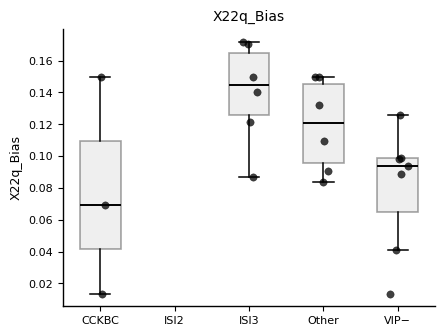

In [43]:
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_mouse_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="LowIQ_ASD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Pos_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Neg_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="DDD_Bias")
# plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="SCZ_Bias")

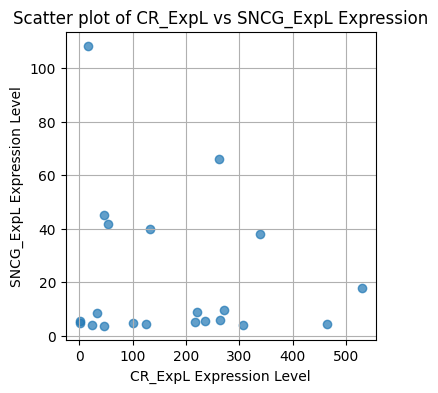

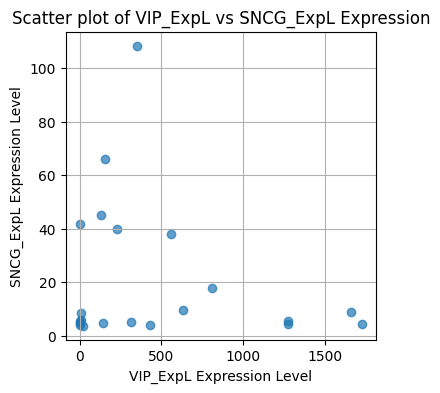

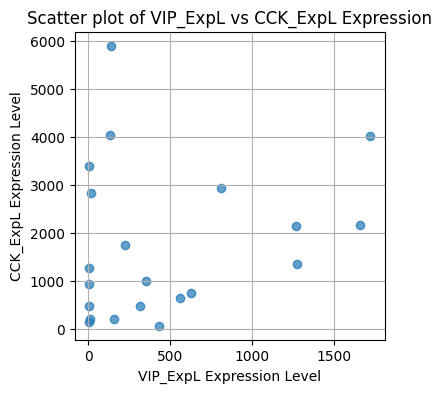

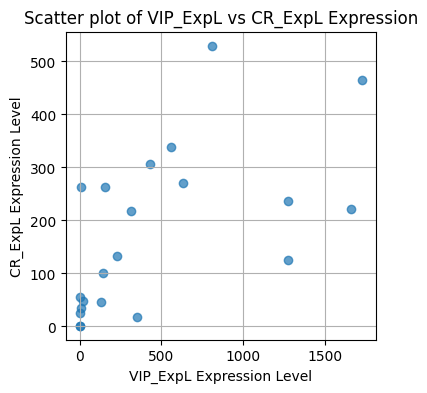

In [272]:
import matplotlib.pyplot as plt

def plot_gene_scatter(df, x_gene, y_gene, x_label=None, y_label=None, title=None, alpha=0.7, figsize=(4,4)):
    """
    Plots a scatter plot between two gene expression columns.

    Parameters:
    - df: DataFrame containing expression columns
    - x_gene: str, column name for x-axis
    - y_gene: str, column name for y-axis
    - x_label: str, label for x-axis (default: x_gene)
    - y_label: str, label for y-axis (default: y_gene)
    - title: str, plot title (default: 'Scatter plot of {x_gene} vs {y_gene} Expression')
    - alpha: float, transparency of points
    - figsize: tuple, figure size
    """
    plt.figure(figsize=figsize)
    plt.scatter(df[x_gene], df[y_gene], alpha=alpha)
    plt.xlabel(x_label if x_label is not None else f"{x_gene} Expression Level")
    plt.ylabel(y_label if y_label is not None else f"{y_gene} Expression Level")
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Scatter plot of {x_gene} vs {y_gene} Expression")
    plt.grid(True)
    plt.show()

# Example usage:
plot_gene_scatter(Biases_CGE_TPM, "CR_ExpL", "SNCG_ExpL")
plot_gene_scatter(Biases_CGE_TPM, "VIP_ExpL", "SNCG_ExpL")
plot_gene_scatter(Biases_CGE_TPM, "VIP_ExpL", "CCK_ExpL")
plot_gene_scatter(Biases_CGE_TPM, "VIP_ExpL", "CR_ExpL")
#plot_gene_scatter(Biases_CGE, "CR_ExpL", "SNCG_ExpL")

In [47]:
test = Biases_CGE[["VIP_ExpL", "CCK_ExpL", "CNR1_ExpL", "CR_ExpL", "M2R_ExpL"]]

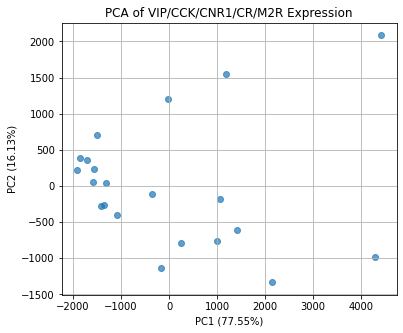

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(test.fillna(0))  # Fill NaNs with 0 for PCA

# Plot the first two principal components
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of VIP/CCK/CNR1/CR/M2R Expression')
plt.grid(True)
plt.show()

In [54]:
test

,VIP_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
293,1273.162043,2144.976661,390.200315,236.512950,44.139466
295,1725.548746,4015.875327,1725.848109,465.405064,11.396987
294,1659.097026,2171.035708,1028.786178,221.195494,21.051680
280,140.480972,5906.345447,2889.098805,100.371054,29.331029
279,132.596978,4046.639007,5543.738644,45.775739,81.213464
281,227.445121,1751.420494,3185.628401,132.975082,18.763641
296,1276.558558,1337.739789,1126.393311,125.861949,44.126669
291,156.030757,203.157170,442.499739,261.964548,77.773270
288,3.590300,1254.107929,126.902538,1.290567,52.434551
284,432.365212,61.745055,281.531728,306.918850,88.216039


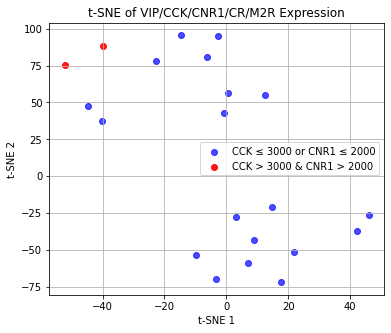

In [61]:
from sklearn.manifold import TSNE

# t-SNE on test (fill NaNs with 0)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(test.fillna(0))

def plot_tsne_mask(X_tsne, mask, mask_label='Masked', unmask_label='Unmasked', 
                   mask_color='red', unmask_color='blue', title='t-SNE of VIP/CCK/CNR1/CR/M2R Expression'):
    """
    Plots t-SNE results with a boolean mask to highlight points.

    Parameters:
    - X_tsne: np.ndarray, shape (n_samples, 2)
    - mask: boolean array, shape (n_samples,)
    - mask_label: label for masked points
    - unmask_label: label for unmasked points
    - mask_color: color for masked points
    - unmask_color: color for unmasked points
    - title: plot title
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 5))
    plt.scatter(X_tsne[~mask, 0], X_tsne[~mask, 1], alpha=0.7, color=unmask_color, label=unmask_label)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.9, color=mask_color, label=mask_label)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
# Highlight points with CCK_ExpL > 3000 and CNR1_ExpL > 2000
mask = (test["CCK_ExpL"] > 3000) & (test["CNR1_ExpL"] > 2000 & (test["VIP_ExpL"] > 100))
plot_tsne_mask(
    X_tsne, 
    mask, 
    mask_label='CCK > 3000 & CNR1 > 2000', 
    unmask_label='CCK ≤ 3000 or CNR1 ≤ 2000'
)


In [67]:
from sklearn.manifold import TSNE

# t-SNE on test (fill NaNs with 0)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(test.fillna(0))

def plot_tsne_multi_mask(X_tsne, masks, labels=None, colors=None, title='t-SNE of VIP/CCK/CNR1/CR/M2R Expression'):
    """
    Plots t-SNE results with multiple boolean masks to highlight groups of points.

    Parameters:
    - X_tsne: np.ndarray, shape (n_samples, 2)
    - masks: list of boolean arrays, each shape (n_samples,)
    - labels: list of str, label for each mask
    - colors: list of str, color for each mask
    - title: plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np

    n = len(masks)
    if labels is None:
        labels = [f"Mask {i+1}" for i in range(n)]
    if colors is None:
        # Use some default matplotlib colors
        default_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
        colors = default_colors[:n]

    plt.figure(figsize=(6, 5), dpi=120)
    already_masked = np.zeros(X_tsne.shape[0], dtype=bool)
    for mask, label, color in zip(masks, labels, colors):
        # Only plot points not already assigned to a previous mask
        mask_to_plot = mask & (~already_masked)
        plt.scatter(X_tsne[mask_to_plot, 0], X_tsne[mask_to_plot, 1], alpha=0.8, color=color, label=label)
        already_masked = already_masked | mask
    # Optionally plot the rest as "Other"
    if not np.all(already_masked):
        plt.scatter(X_tsne[~already_masked, 0], X_tsne[~already_masked, 1], alpha=0.3, color='lightgray', label='Other')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True)
    plt.show()



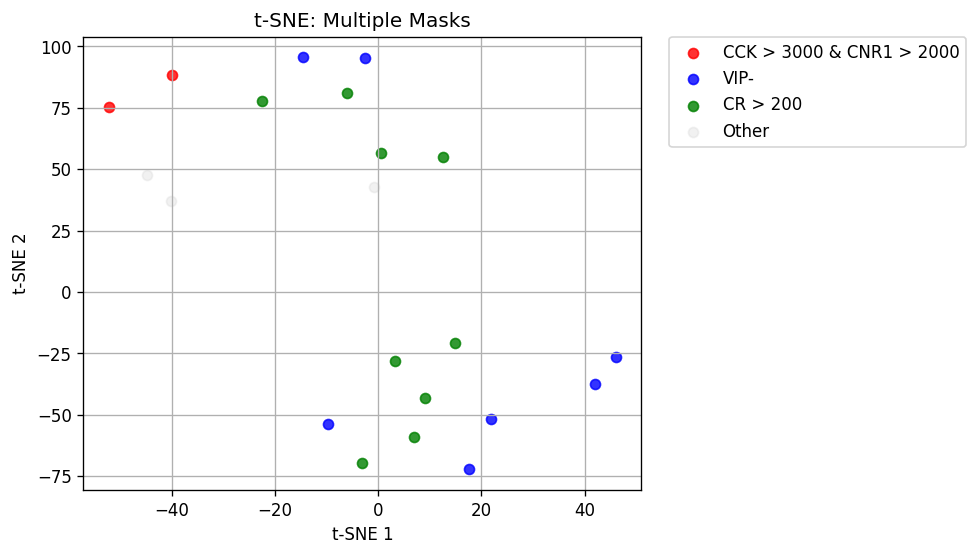

In [69]:

# Example usage:
# Define multiple masks
mask1 = (test["CCK_ExpL"] > 3000) & (test["CNR1_ExpL"] > 2000)
mask2 = (test["VIP_ExpL"] < 100)
mask3 = (test["CR_ExpL"] > 200)
masks = [mask1, mask2, mask3]
labels = ['CCK > 3000 & CNR1 > 2000', 'VIP-', 'CR > 200']
colors = ['red', 'blue', 'green']

plot_tsne_multi_mask(
    X_tsne,
    masks,
    labels=labels,
    colors=colors,
    title='t-SNE: Multiple Masks'
)

In [109]:
PBS_CGE = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"].copy()
PBS_CGE["VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], PBS_CGE.index]
PBS_CGE["SST_ExpL"] = TPM.loc[GeneSymbol2Entrez["SST"], PBS_CGE.index]
PBS_CGE["PVALB_ExpL"] = TPM.loc[GeneSymbol2Entrez["PVALB"], PBS_CGE.index]
PBS_CGE["NPY_ExpL"] = TPM.loc[GeneSymbol2Entrez["NPY"], PBS_CGE.index]
PBS_CGE["CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], PBS_CGE.index]
PBS_CGE["CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], PBS_CGE.index]
PBS_CGE["CR_ExpL"] = TPM.loc[GeneSymbol2Entrez["CALB2"], PBS_CGE.index]
PBS_CGE["M2R_ExpL"] = TPM.loc[GeneSymbol2Entrez["CHRM2"], PBS_CGE.index]

PBS_OtherIN = HumanCT_res_df_GeneL[
    (HumanCT_res_df_GeneL["Supercluster"] == "MGE interneuron") | 
    (HumanCT_res_df_GeneL["Supercluster"] == "LAMP5-LHX6 and Chandelier")
].copy()
PBS_OtherIN["VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], PBS_OtherIN.index]
PBS_OtherIN["SST_ExpL"] = TPM.loc[GeneSymbol2Entrez["SST"], PBS_OtherIN.index]
PBS_OtherIN["PVALB_ExpL"] = TPM.loc[GeneSymbol2Entrez["PVALB"], PBS_OtherIN.index]
PBS_OtherIN["NPY_ExpL"] = TPM.loc[GeneSymbol2Entrez["NPY"], PBS_OtherIN.index]
PBS_OtherIN["CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], PBS_OtherIN.index]
PBS_OtherIN["CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], PBS_OtherIN.index]
PBS_OtherIN["CR_ExpL"] = TPM.loc[GeneSymbol2Entrez["CALB2"], PBS_OtherIN.index]
PBS_OtherIN["M2R_ExpL"] = TPM.loc[GeneSymbol2Entrez["CHRM2"], PBS_OtherIN.index]


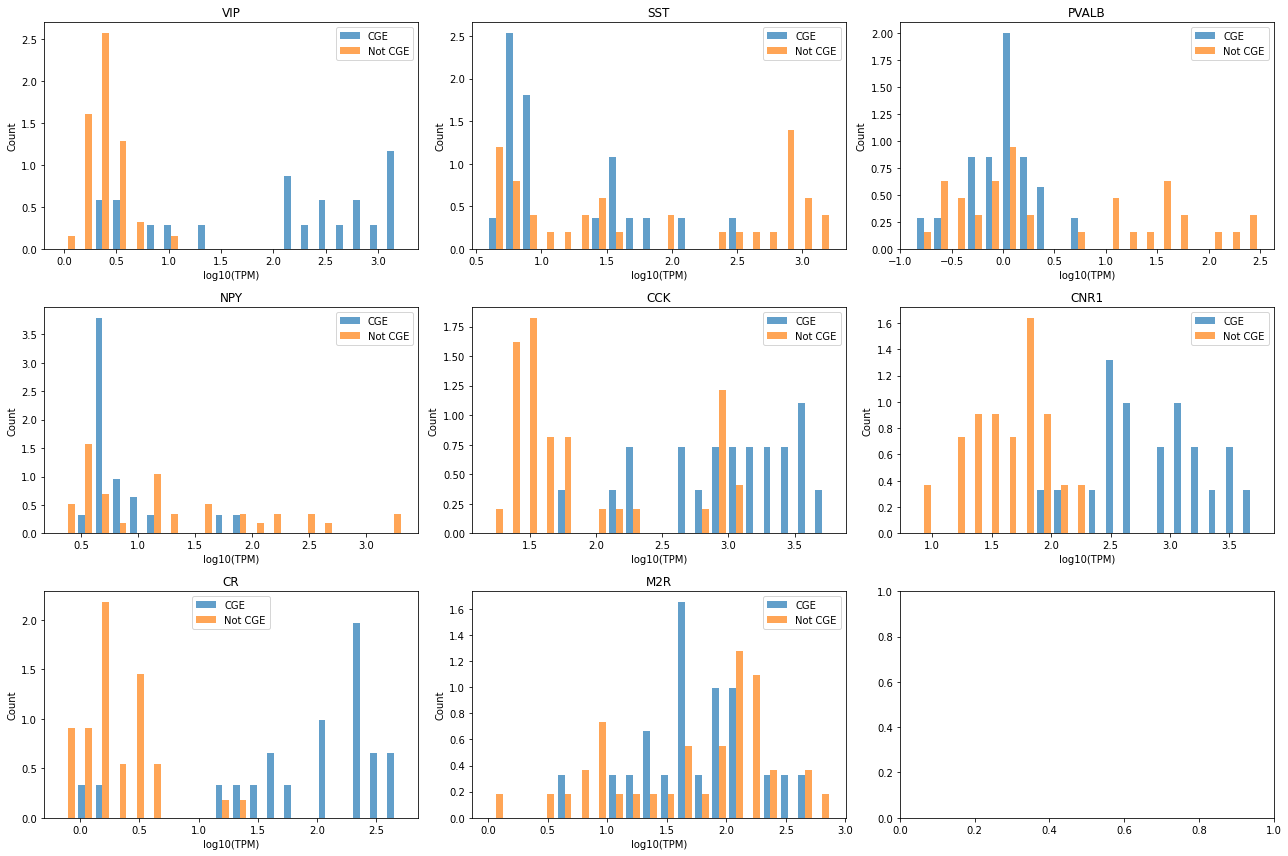

In [113]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
genes = ["VIP_ExpL", "SST_ExpL", "PVALB_ExpL", "NPY_ExpL", "CCK_ExpL", "CNR1_ExpL", "CR_ExpL", "M2R_ExpL"]
titles = ["VIP", "SST", "PVALB", "NPY", "CCK", "CNR1", "CR", "M2R"]

for ax, gene, title in zip(axes.flat, genes, titles):
    ax.hist(
        [np.log10(PBS_CGE[gene]), np.log10(PBS_OtherIN[gene])],
        label=["CGE", "Not CGE"],
        alpha=0.7,
        bins=20,
        density=True
    )
    ax.set_title(title)
    ax.set_xlabel('log10(TPM)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [95]:
VIP_Cutoff = 100
CCK_Cutoff = 3000
CR_Cutoff = 100
M2R_Cutoff = 100

VIP_Pos = PBS_CGE[PBS_CGE["VIP_ExpL"] > VIP_Cutoff]
VIP_Neg = PBS_CGE[PBS_CGE["VIP_ExpL"] < VIP_Cutoff]

CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

1 1 7 5


In [118]:
PBS_CGE[PBS_CGE["CCK_ExpL"] > 5000]

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,...,p_rho_perm_FDR,p_beta_perm_FDR,VIP_ExpL,SST_ExpL,PVALB_ExpL,NPY_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
280,280,CGE interneuron,-0.255926,0.056934,-0.353467,0.007533,-15.810068,-27.225595,-4.394541,65.56825,...,0.242574,0.043795,140.480972,6.144562,1.154882,5.522703,5906.345447,2889.098805,100.371054,29.331029


In [114]:
PBS_CGE[PBS_CGE["p_beta_perm_FDR"]>0.05]

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,...,p_rho_perm_FDR,p_beta_perm_FDR,VIP_ExpL,SST_ExpL,PVALB_ExpL,NPY_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
289,289,CGE interneuron,-0.203715,0.132087,-0.323667,0.014959,-15.203871,-27.329854,-3.077887,64.179504,...,0.373190,0.064736,316.724856,6.227508,2.384285,5.383215,467.042852,311.111976,217.591302,117.626962
291,291,CGE interneuron,-0.206313,0.127122,-0.323655,0.014963,-14.513066,-26.088579,-2.937553,63.702465,...,0.369911,0.065462,156.030757,4.858449,1.028272,6.142429,203.157170,442.499739,261.964548,77.773270
277,277,CGE interneuron,-0.369518,0.005066,-0.318362,0.016791,-14.105240,-25.564181,-2.646299,65.260161,...,0.086438,0.065462,2.331941,8.332804,0.279833,3.357995,127.417281,340.712181,54.318685,393.538429
285,285,CGE interneuron,-0.279420,0.037018,-0.312624,0.018985,-13.743238,-25.135920,-2.350555,64.320598,...,0.205581,0.066845,560.224969,24.909144,0.725253,14.043535,637.088576,523.105158,338.284360,51.967674
287,287,CGE interneuron,-0.245992,0.067623,-0.303412,0.023015,-14.583292,-27.078498,-2.088086,64.722478,...,0.293996,0.066845,2.027901,47.242590,2.361712,4.957093,934.749859,84.779631,1.322726,20.967498
290,290,CGE interneuron,-0.178627,0.187773,-0.315724,0.017771,-13.850031,-25.206227,-2.493834,63.556657,...,0.432442,0.066845,630.893903,6.648101,1.328713,4.838693,745.829871,216.244674,270.776333,342.749052
288,288,CGE interneuron,-0.250162,0.062955,-0.312799,0.018914,-13.920546,-25.453030,-2.388062,64.354683,...,0.293996,0.066845,3.590300,6.168200,1.452292,4.395692,1254.107929,126.902538,1.290567,52.434551
282,282,CGE interneuron,-0.192590,0.155010,-0.291162,0.029471,-12.268879,-23.267168,-1.270589,64.566969,...,0.386087,0.078297,19.160384,42.692030,6.364329,5.613318,2823.374109,1590.523834,47.111438,138.609489
283,283,CGE interneuron,-0.204365,0.130832,-0.293213,0.028296,-12.842823,-24.267626,-1.418020,64.682476,...,0.369911,0.088462,11.745396,109.905234,0.994180,5.498781,190.187434,827.570901,263.712741,57.759197


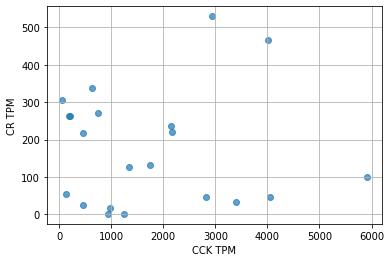

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
Marker1 = "CCK"
Marker2 = "CR"
plt.scatter(PBS_CGE[f"{Marker1}_ExpL"], PBS_CGE[f"{Marker2}_ExpL"], alpha=0.7)
plt.xlabel(f"{Marker1} TPM")
plt.ylabel(f"{Marker2} TPM")
plt.grid(True)
plt.show()